In [1]:
! pip install tomotopy

Defaulting to user installation because normal site-packages is not writeable


In [7]:
from tqdm import notebook

In [13]:
import tomotopy as tp
import os

# создаем модель. нужно указать количество тем, можно указать сколько самых частотных слов удалить
#  и минимум документов, в кот-х встречается слово, чтобы учитывалось моделью
mdl = tp.LDAModel(k=7, rm_top=50, min_df=6)

In [ ]:
# загружаем стоп-словарь (нужно указать путь!)
swl = []
with open(r"кswl.txt", encoding="utf-8") as swl_file:
    swl.extend(swl_file.readlines())

In [15]:
# создаем корпус, который передадим модели
# можно туда просто передать стоп-список, можно посложнее, как тут: заодно удаляем слова короче трех букв
corpus = tp.utils.Corpus(stopwords=lambda x: len(x) <= 2 or x in swl)

In [16]:
# указать путь к папке с текстами
path = r'C:\Users\Aндрей\Desktop\Митрофанова\TM\annot'
files = os.listdir(path)
for f in files:
    # добавляем их в корпус
    with open(path + '\\' +f, encoding="utf-8") as text:
        corpus.add_doc(text.read().strip().split())

In [17]:
# передаем корпус модели, которую уже создали выше
mdl.add_corpus(corpus)

# обучаем модель
for i in notebook.tqdm(range(0, 100, 5)):
    mdl.train(10)
    print('Iteration: {}\tLog-likelihood: {}'.format(i, mdl.ll_per_word))

mdl.summary()

  0%|          | 0/20 [00:00<?, ?it/s]

Iteration: 0	Log-likelihood: -8.665075600994543
Iteration: 5	Log-likelihood: -8.370138537789288
Iteration: 10	Log-likelihood: -8.290936502570851
Iteration: 15	Log-likelihood: -8.24960245114063
Iteration: 20	Log-likelihood: -8.21896117577697
Iteration: 25	Log-likelihood: -8.201159956032328
Iteration: 30	Log-likelihood: -8.186286328028892
Iteration: 35	Log-likelihood: -8.171364018928983
Iteration: 40	Log-likelihood: -8.16448573812166
Iteration: 45	Log-likelihood: -8.161212705939645
Iteration: 50	Log-likelihood: -8.155163873016376
Iteration: 55	Log-likelihood: -8.149526890373998
Iteration: 60	Log-likelihood: -8.146444517259452
Iteration: 65	Log-likelihood: -8.1409816750998
Iteration: 70	Log-likelihood: -8.137631758822005
Iteration: 75	Log-likelihood: -8.135348705694332
Iteration: 80	Log-likelihood: -8.133967823377876
Iteration: 85	Log-likelihood: -8.135594738068583
Iteration: 90	Log-likelihood: -8.13349266153365
Iteration: 95	Log-likelihood: -8.129221134161849
<Basic Info>
| LDAModel (cur

In [18]:
# распределения слов по темам (pprint чтобы немножко аккуратней был вид)

from pprint import pprint
for k in range(mdl.k):
    print(f"Topic {k}")
    pprint(mdl.get_topic_words(k, top_n=10))

Topic 0
[('земля', 0.01168978400528431),
 ('вода', 0.011451220139861107),
 ('если', 0.010051646269857883),
 ('них', 0.008206753060221672),
 ('лишь', 0.0076819127425551414),
 ('огромный', 0.007204785011708736),
 ('наш', 0.006679944694042206),
 ('животное', 0.006679944694042206),
 ('вид', 0.006330051459372044),
 ('тело', 0.006139200180768967)]
Topic 1
[('даже', 0.010222787968814373),
 ('какой', 0.008986826986074448),
 ('него', 0.007496742065995932),
 ('видеть', 0.007161762099713087),
 ('говорить', 0.0071386597119271755),
 ('глаз', 0.005798738915473223),
 ('среди', 0.005764085799455643),
 ('дом', 0.005706330761313438),
 ('город', 0.0055908202193677425),
 ('над', 0.005359799135476351)]
Topic 2
[('учёный', 0.01179581694304943),
 ('исследование', 0.009979537688195705),
 ('университет', 0.009673423133790493),
 ('теория', 0.008204073645174503),
 ('книга', 0.007632659748196602),
 ('война', 0.0073877680115401745),
 ('родиться', 0.0070612458512187),
 ('премия', 0.007040838245302439),
 ('наука', 0

In [19]:
! pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


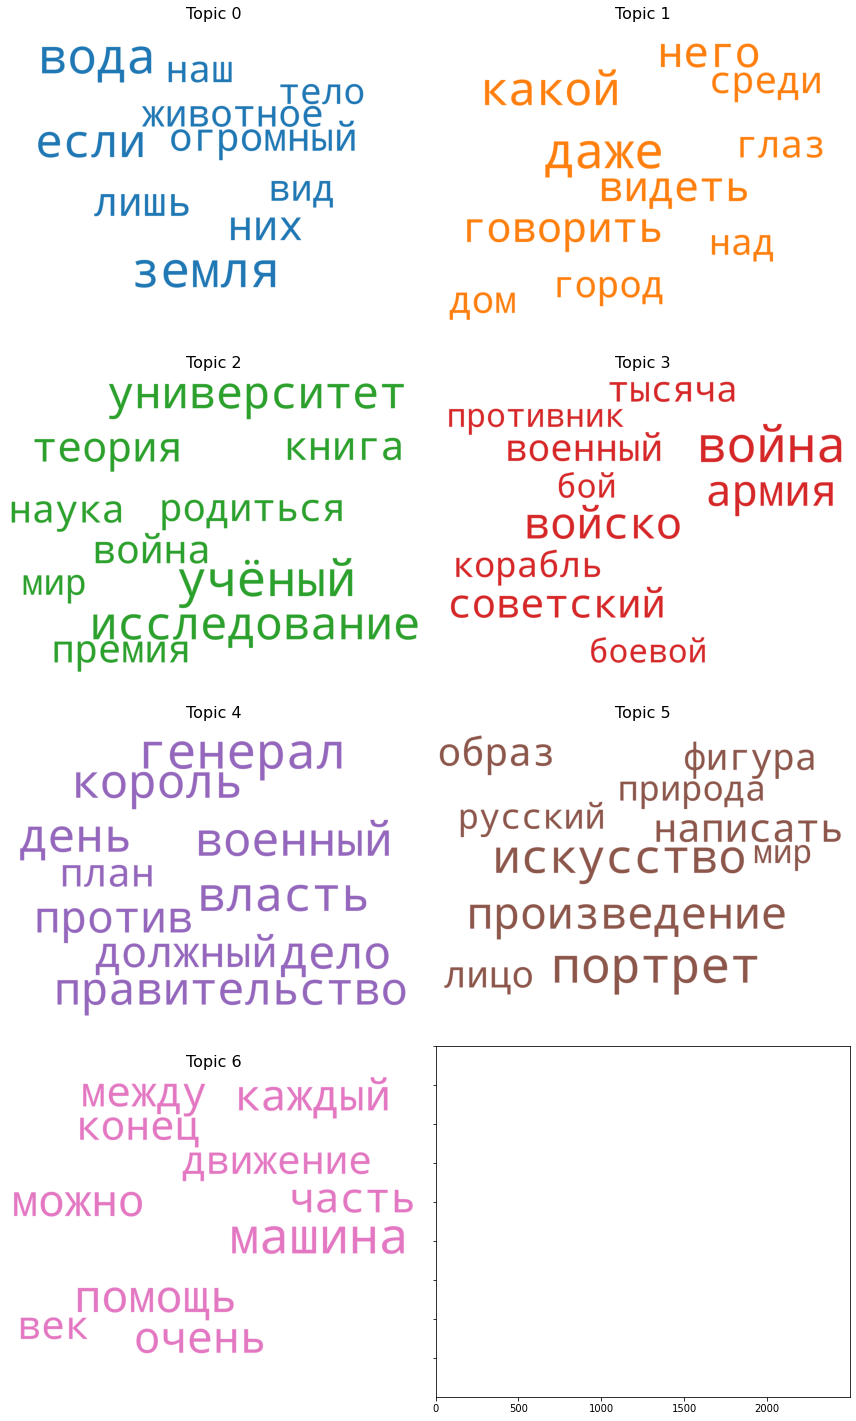

In [22]:
# визуализаця
# тут тоже нужно немного менять настройки размера в зависимости от количества тем plt.subplots(10, 3, figsize=(10,40)
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

topics = list((k, mdl.get_topic_words(k, top_n=10)) for k in range(mdl.k))

cols = [color for name, color in list(mcolors.TABLEAU_COLORS.items()) * (mdl.k // 4)]  # more colors: 'mcolors.XKCD_COLORS'

cloud = WordCloud(background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)


fig, axes = plt.subplots(4, 2, figsize=(12,20), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    if i >= len(topics):
        break
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud.generate_from_frequencies(topic_words, max_font_size=300)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
    plt.gca().axis('off')


plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()

# сохраняем картинку в хорошем разрешении (мало ли)
plt.savefig("topics.png", dpi=100)
plt.show()

https://dougfenstermacher.com/blog/nlp-exploration-topic-models

In [24]:
import tomotopy as tp

corpus = tp.utils.Corpus(tokenizer=tp.utils.SimpleTokenizer(), stopwords=['.'])
# data_feeder yields a tuple of (raw string, user data) or a str (raw string)
corpus.process(open(r"C:\Users\Aндрей\Desktop\Митрофанова\TM\annot\Новый текстовый документ_annot.txt", encoding='utf-8'))

# make LDA model and train
mdl = tp.LDAModel(k=20, min_cf=10, min_df=5, corpus=corpus)
mdl.train(0)
print('Num docs:', len(mdl.docs), ', Vocab size:', len(mdl.used_vocabs), ', Num words:', mdl.num_words)
print('Removed top words:', mdl.removed_top_words)
for i in range(0, 1000, 10):
    mdl.train(10)
    print('Iteration: {}\tLog-likelihood: {}'.format(i, mdl.ll_per_word))

# extract candidates for auto topic labeling
extractor = tp.label.PMIExtractor(min_cf=10, min_df=5, max_len=5, max_cand=10000)
cands = extractor.extract(mdl)

# ranking the candidates of labels for a specific topic
labeler = tp.label.FoRelevance(mdl, cands, min_df=5, smoothing=1e-2, mu=0.25)
for k in range(mdl.k):
    print("== Topic #{} ==".format(k))
    print("Labels:", ', '.join(label for label, score in labeler.get_topic_labels(k, top_n=5)))
    for word, prob in mdl.get_topic_words(k, top_n=10):
        print(word, prob, sep='\t')
    print()

Num docs: 2338 , Vocab size: 2402 , Num words: 147104
Removed top words: []
Iteration: 0	Log-likelihood: -7.993497101892712
Iteration: 10	Log-likelihood: -7.743863528234973
Iteration: 20	Log-likelihood: -7.6285694978557075
Iteration: 30	Log-likelihood: -7.5660573102619715
Iteration: 40	Log-likelihood: -7.514450662237975
Iteration: 50	Log-likelihood: -7.471285016110018
Iteration: 60	Log-likelihood: -7.435660663617976
Iteration: 70	Log-likelihood: -7.405784431346772
Iteration: 80	Log-likelihood: -7.376836156042458
Iteration: 90	Log-likelihood: -7.341183909685455
Iteration: 100	Log-likelihood: -7.319052704801178
Iteration: 110	Log-likelihood: -7.301914987070634
Iteration: 120	Log-likelihood: -7.281827085440963
Iteration: 130	Log-likelihood: -7.257051849277876
Iteration: 140	Log-likelihood: -7.244035168457918
Iteration: 150	Log-likelihood: -7.227734593091679
Iteration: 160	Log-likelihood: -7.205212169605813
Iteration: 170	Log-likelihood: -7.1936556163142855
Iteration: 180	Log-likelihood: -

In [28]:
import tomotopy as tp

file_name = r"C:\Users\Aндрей\Desktop\Митрофанова\TM\annot\Новый текстовый документ_annot.txt"

mdl = tp.HLDAModel(depth=3, min_cf=100)
for line in open(file_name, 'r', encoding='utf-8'):
    document = line.strip().split()
    mdl.add_doc(document)
    

print('Training model by iterating over the corpus 100 times, 10 iterations at a time')
iterations = 10
for i in range(0, 100, iterations):
    mdl.train(iterations)
    print('Iteration: #{}\tLog-likelihood: {}'.format(i, mdl.ll_per_word))

for k in range(mdl.k):
    if not mdl.is_live_topic(k):
        continue
    print('child of topic #%s - Level: %r, number of documents' % (mdl.parent_topic(k), mdl.level(k), mdl.num_docs_of_topic(k)) )
    print('Top 10 words of global topic #{}'.format(k))
    print(mdl.get_topic_words(k, top_n=10))

Training model by iterating over the corpus 100 times, 10 iterations at a time
Iteration: #0	Log-likelihood: -inf
Iteration: #10	Log-likelihood: -inf
Iteration: #20	Log-likelihood: -inf
Iteration: #30	Log-likelihood: -inf
Iteration: #40	Log-likelihood: -inf
Iteration: #50	Log-likelihood: -inf
Iteration: #60	Log-likelihood: -inf
Iteration: #70	Log-likelihood: -inf
Iteration: #80	Log-likelihood: -inf
Iteration: #90	Log-likelihood: -inf


TypeError: not all arguments converted during string formatting

https://github.com/bab2min/tomotopy?ysclid=laasprzdlj292693752

https://github.com/bab2min/tomotopy/blob/main/examples/

In [31]:
#Hierarchical LDA

import tomotopy as tp

file_name = r"C:\Users\Aндрей\Desktop\Митрофанова\TM\annot\Новый текстовый документ_annot.txt"

mdl = tp.HLDAModel(depth=3, min_cf=100)
for line in open(file_name, 'r', encoding='utf-8'):
    document = line.strip().split()
    mdl.add_doc(document)

print('Training model by iterating over the corpus 100 times, 10 iterations at a time')
iterations = 10
for i in range(0, 100, iterations):
    mdl.train(iterations)
    print('Iteration: #{}\tLog-likelihood: {}'.format(i, mdl.ll_per_word))

for k in range(mdl.k):
    if not mdl.is_live_topic(k):
        continue
    print('child of topic #%s - Level: %r, number of documents' % (mdl.parent_topic(k), mdl.level(k), mdl.num_docs_of_topic(k)) )
    print('Top 10 words of global topic #{}'.format(k))
    print(mdl.get_topic_words(k, top_n=10))

Training model by iterating over the corpus 100 times, 10 iterations at a time
Iteration: #0	Log-likelihood: -inf
Iteration: #10	Log-likelihood: -inf
Iteration: #20	Log-likelihood: -inf
Iteration: #30	Log-likelihood: -inf
Iteration: #40	Log-likelihood: -inf
Iteration: #50	Log-likelihood: -inf
Iteration: #60	Log-likelihood: -inf
Iteration: #70	Log-likelihood: -inf
Iteration: #80	Log-likelihood: -inf
Iteration: #90	Log-likelihood: -inf


TypeError: not all arguments converted during string formatting

In [32]:
#Partially labelled LDA

import tomotopy as tp

corpus = tp.utils.Corpus(tokenizer=tp.utils.SimpleTokenizer(), stopwords=['.'])
# data_feeder yields a tuple of (raw string, user data) or a str (raw string)
corpus.process(open(file_name, encoding='utf-8'))

# make LDA model and train
mdl = tp.LDAModel(k=20, min_cf=10, min_df=5, corpus=corpus)
mdl.train(0)
print('Num docs:', len(mdl.docs), ', Vocab size:', len(mdl.used_vocabs), ', Num words:', mdl.num_words)
print('Removed top words:', mdl.removed_top_words)
for i in range(0, 1000, 10):
    mdl.train(10)
    print('Iteration: {}\tLog-likelihood: {}'.format(i, mdl.ll_per_word))

# extract candidates for auto topic labeling
extractor = tp.label.PMIExtractor(min_cf=10, min_df=5, max_len=5, max_cand=10000)
cands = extractor.extract(mdl)

# ranking the candidates of labels for a specific topic
labeler = tp.label.FoRelevance(mdl, cands, min_df=5, smoothing=1e-2, mu=0.25)
for k in range(mdl.k):
    print("== Topic #{} ==".format(k))
    print("Labels:", ', '.join(label for label, score in labeler.get_topic_labels(k, top_n=5)))
    for word, prob in mdl.get_topic_words(k, top_n=10):
        print(word, prob, sep='\t')
    print()

Num docs: 2338 , Vocab size: 2402 , Num words: 147104
Removed top words: []
Iteration: 0	Log-likelihood: -7.9762491173094086
Iteration: 10	Log-likelihood: -7.7340324397936495
Iteration: 20	Log-likelihood: -7.615473602268961
Iteration: 30	Log-likelihood: -7.534053301257571
Iteration: 40	Log-likelihood: -7.484794449025701
Iteration: 50	Log-likelihood: -7.446973246974234
Iteration: 60	Log-likelihood: -7.407169264616039
Iteration: 70	Log-likelihood: -7.369982902340475
Iteration: 80	Log-likelihood: -7.343184399216344
Iteration: 90	Log-likelihood: -7.319456944787907
Iteration: 100	Log-likelihood: -7.296359105124601
Iteration: 110	Log-likelihood: -7.275537436333892
Iteration: 120	Log-likelihood: -7.261255148508924
Iteration: 130	Log-likelihood: -7.238575760648505
Iteration: 140	Log-likelihood: -7.225839329632443
Iteration: 150	Log-likelihood: -7.224834376722834
Iteration: 160	Log-likelihood: -7.208902211647504
Iteration: 170	Log-likelihood: -7.19404631065744
Iteration: 180	Log-likelihood: -7.